# Exhaust Brake / Backpressure Proxy Investigation (Population)

This notebook loads the **partitioned Parquet dataset** you generated:

- `data/analysis/vin_event_samples_slim.parquet/vin=VINxxxxx/part_*.parquet`

and builds **population-level correlation and clustering visuals** under *strict operating-condition gating*.

**Target (backpressure/retard proxy):** `Act_RetardPctTorqExh`

> Tip: Keep this notebook in your project root so relative paths like `data/analysis/...` work.


## 0) Imports + config
- Uses **matplotlib** (no seaborn)
- Reads **all Parquet partitions** (iterates VIN folders to avoid schema merge issues)


In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths (make robust to running from project root or notebooks/)
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SLIM_DS_ROOT = PROJECT_ROOT / "data/analysis/vin_event_samples_slim.parquet"
if not SLIM_DS_ROOT.exists():
    raise FileNotFoundError(f"Dataset not found at: {SLIM_DS_ROOT.resolve()}")

# Columns to load (keep small for speed)
COLS = [
    "vin",
    "event_id",
    "event_start_time",
    "event_end_time",
    "timestamp",           # time column in slim output
    "speed_band",
    "label",               # inspection label (GOOD/BAD/UNKNOWN) - do NOT treat as global truth
    "Act_RetardPctTorqExh",
    "EngSpeed",
    "VehSpeedEng",
    "TrRgAttai",
    "TransTorqConvLockupEngaged",
    "EngRetarderStat_1587",
    "AccelPedalPos",
    "AccelPedalPos_1587",
    "FuelRate",
    "EngPctTorq",
    "EngDmdPctTorq",
    "BoostPres",
    "BrakeSwitch",
    "ABS_RetCont_1587",
    "ABS_BrkCtl_1587",
]

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)


## 1) Load ALL partitions safely

Why we do this:
- `pd.read_parquet(SLIM_DS_ROOT)` can fail when Arrow tries to **merge schemas/types** across partitions.
- Iterating VIN partitions avoids that (we coerce `vin` to string afterwards).


In [2]:

def list_vin_partitions(ds_root: Path):
    # expects hive-style partitions: vin=VIN02756
    return sorted([p for p in ds_root.glob("vin=*") if p.is_dir()])

def load_all_partitions(ds_root: Path, cols=None, max_rows=None):
    parts = list_vin_partitions(ds_root)
    if not parts:
        raise FileNotFoundError(f"No partitions found under: {ds_root}")

    dfs = []
    total = 0

    for i, part in enumerate(parts, start=1):
        try:
            if cols is None:
                d = pd.read_parquet(part)
            else:
                schema_cols = pd.read_parquet(part, engine="pyarrow").columns.tolist()
                use_cols = [c for c in cols if c in schema_cols]
                d = pd.read_parquet(part, columns=use_cols)

            if "vin" in d.columns:
                d["vin"] = d["vin"].astype(str)

            dfs.append(d)
            total += len(d)

            if (i % 10 == 0) or (i == len(parts)):
                print(f"...loaded {i}/{len(parts)} partitions | rows={total:,}")

            if max_rows is not None and total >= max_rows:
                print(f"Reached max_rows={max_rows:,}. Stopping early.")
                break

        except Exception as e:
            print(f"⚠️ Failed partition {part.name}: {e}")

    if not dfs:
        raise RuntimeError("No partitions loaded successfully.")
    return pd.concat(dfs, ignore_index=True)

# Load everything (can be big). If you hit RAM limits, set max_rows (e.g., 2_000_000).
df = load_all_partitions(SLIM_DS_ROOT, cols=COLS, max_rows=None)

print("Loaded df:", df.shape)
df.head()


...loaded 10/91 partitions | rows=2,306,543
...loaded 20/91 partitions | rows=4,960,036
...loaded 30/91 partitions | rows=6,206,191
...loaded 40/91 partitions | rows=6,695,781
...loaded 50/91 partitions | rows=7,126,742
...loaded 60/91 partitions | rows=7,555,497
...loaded 70/91 partitions | rows=8,955,237
...loaded 80/91 partitions | rows=10,085,676
...loaded 90/91 partitions | rows=10,802,134
...loaded 91/91 partitions | rows=10,802,228
Loaded df: (10802228, 18)


,vin,event_id,event_start_time,event_end_time,timestamp,speed_band,label,Act_RetardPctTorqExh,EngSpeed,VehSpeedEng,TrRgAttai,TransTorqConvLockupEngaged,EngRetarderStat_1587,AccelPedalPos,AccelPedalPos_1587,FuelRate,EngPctTorq,BoostPres
0,VIN00910,0,2016-08-10 17:15:42,2016-08-10 17:15:46,2016-08-10 17:15:22,20-35,UNKNOWN,0.0,1507.500,20.373119,13388.0,1.0,0.0,74.400002,75.599998,13.618070,71.0,16.82464
1,VIN00910,0,2016-08-10 17:15:42,2016-08-10 17:15:46,2016-08-10 17:15:23,20-35,UNKNOWN,0.0,1592.000,22.533390,13644.0,1.0,0.0,54.000000,55.200001,12.402878,50.0,14.79408
2,VIN00910,0,2016-08-10 17:15:42,2016-08-10 17:15:46,2016-08-10 17:15:24,20-35,UNKNOWN,0.0,1668.500,23.794559,13644.0,1.0,0.0,47.200001,48.000000,10.144207,44.0,11.02304
3,VIN00910,0,2016-08-10 17:15:42,2016-08-10 17:15:46,2016-08-10 17:15:25,20-35,UNKNOWN,0.0,1353.125,24.912359,13644.0,1.0,0.0,41.200001,44.000000,9.113935,37.0,11.60320
4,VIN00910,0,2016-08-10 17:15:42,2016-08-10 17:15:46,2016-08-10 17:15:26,20-35,UNKNOWN,0.0,1355.125,25.816320,13900.0,1.0,0.0,22.400000,24.799999,9.312065,19.0,9.28256


## 2) Clean + derive helper features

In [3]:

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

df["AbsRetard"] = -df["Act_RetardPctTorqExh"]  # magnitude (positive = stronger retard)
df["NormRetard_perRPM"] = df["AbsRetard"] / df["EngSpeed"].replace(0, np.nan)

for c in ["Act_RetardPctTorqExh", "EngSpeed", "VehSpeedEng"]:
    if c in df.columns:
        print(c, "non-null %:", float(100*df[c].notna().mean()))

df[["vin","event_id","timestamp","Act_RetardPctTorqExh","EngSpeed","VehSpeedEng","TrRgAttai"]].head()


Act_RetardPctTorqExh non-null %: 100.0
EngSpeed non-null %: 100.0
VehSpeedEng non-null %: 100.0


,vin,event_id,timestamp,Act_RetardPctTorqExh,EngSpeed,VehSpeedEng,TrRgAttai
0,VIN00910,0,2016-08-10 17:15:22,0.0,1507.500,20.373119,13388.0
1,VIN00910,0,2016-08-10 17:15:23,0.0,1592.000,22.533390,13644.0
2,VIN00910,0,2016-08-10 17:15:24,0.0,1668.500,23.794559,13644.0
3,VIN00910,0,2016-08-10 17:15:25,0.0,1353.125,24.912359,13644.0
4,VIN00910,0,2016-08-10 17:15:26,0.0,1355.125,25.816320,13900.0


## 3) Define the "right condition" gate

Start strict, then loosen.


In [4]:

GATE = {
    "min_engspeed": 1400,    # rpm
    "max_engspeed": 2200,    # rpm
    "min_speed": 20,         # mph
    "max_speed": 60,         # mph
    "max_accel": 2.0,        # % pedal
    "max_engpcttorq": 5.0,   # % (torque request approx 0)
    "require_lockup": True,
    "require_retarder_on": True,
    "exclude_abs": True,
    "require_brake_switch": False,
}

def get_accel_col(d: pd.DataFrame):
    if "AccelPedalPos" in d.columns:
        return "AccelPedalPos"
    if "AccelPedalPos_1587" in d.columns:
        return "AccelPedalPos_1587"
    return None

def gate_rows(d: pd.DataFrame, gate: dict):
    x = d.copy()

    needed = ["Act_RetardPctTorqExh","EngSpeed","VehSpeedEng"]
    missing = [c for c in needed if c not in x.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    x = x[(x["EngSpeed"] >= gate["min_engspeed"]) & (x["EngSpeed"] <= gate["max_engspeed"])]
    x = x[(x["VehSpeedEng"] >= gate["min_speed"]) & (x["VehSpeedEng"] <= gate["max_speed"])]

    ac = get_accel_col(x)
    if ac:
        x = x[x[ac] <= gate["max_accel"]]

    if "EngPctTorq" in x.columns:
        x = x[x["EngPctTorq"] <= gate["max_engpcttorq"]]
    if "EngDmdPctTorq" in x.columns:
        x = x[x["EngDmdPctTorq"] <= gate["max_engpcttorq"]]

    if gate["require_lockup"] and "TransTorqConvLockupEngaged" in x.columns:
        x = x[x["TransTorqConvLockupEngaged"] == 1]

    if gate["require_retarder_on"] and "EngRetarderStat_1587" in x.columns:
        x = x[x["EngRetarderStat_1587"] == 1]

    if gate["require_brake_switch"] and "BrakeSwitch" in x.columns:
        x = x[x["BrakeSwitch"] == 1]

    if gate["exclude_abs"]:
        if "ABS_RetCont_1587" in x.columns:
            x = x[x["ABS_RetCont_1587"] == 0]
        if "ABS_BrkCtl_1587" in x.columns:
            x = x[x["ABS_BrkCtl_1587"] == 0]

    return x

g = gate_rows(df, GATE)
print("Gated rows:", len(g), "out of", len(df))
g.head()


Gated rows: 1099923 out of 10802228


,vin,event_id,event_start_time,event_end_time,timestamp,speed_band,label,Act_RetardPctTorqExh,EngSpeed,VehSpeedEng,TrRgAttai,TransTorqConvLockupEngaged,EngRetarderStat_1587,AccelPedalPos,AccelPedalPos_1587,FuelRate,EngPctTorq,BoostPres,AbsRetard,NormRetard_perRPM
203,VIN00910,4,2016-08-11 12:41:38,2016-08-11 12:41:47,2016-08-11 12:41:32,20-35,UNKNOWN,-52.0,1405.875,26.912251,13900.0,1.0,1.0,0.0,2.8,0.0,0.0,1.16032,52.0,0.036988
248,VIN00910,5,2016-08-11 12:44:11,2016-08-11 12:44:20,2016-08-11 12:44:00,20-35,UNKNOWN,-58.0,1594.750,30.761370,13900.0,1.0,1.0,0.0,2.8,0.0,0.0,1.45040,58.0,0.036369
249,VIN00910,5,2016-08-11 12:44:11,2016-08-11 12:44:20,2016-08-11 12:44:01,20-35,UNKNOWN,-57.0,1586.625,30.270510,13900.0,1.0,1.0,0.0,2.8,0.0,0.0,1.45040,57.0,0.035925
250,VIN00910,5,2016-08-11 12:44:11,2016-08-11 12:44:20,2016-08-11 12:44:02,20-35,UNKNOWN,-55.0,1537.250,29.446739,13900.0,1.0,1.0,0.0,2.8,0.0,0.0,1.16032,55.0,0.035778
251,VIN00910,5,2016-08-11 12:44:11,2016-08-11 12:44:20,2016-08-11 12:44:03,20-35,UNKNOWN,-54.0,1467.500,28.333799,13900.0,1.0,1.0,0.0,2.8,0.0,0.0,1.16032,54.0,0.036797


## 4) Population plots (best for finding clusters)

Individual figures:
1) Scatter: `Act_RetardPctTorqExh` vs `EngSpeed`  
2) Hexbin density  
3) Histogram: `AbsRetard / EngSpeed`  
4) Correlation heatmap (Pearson)


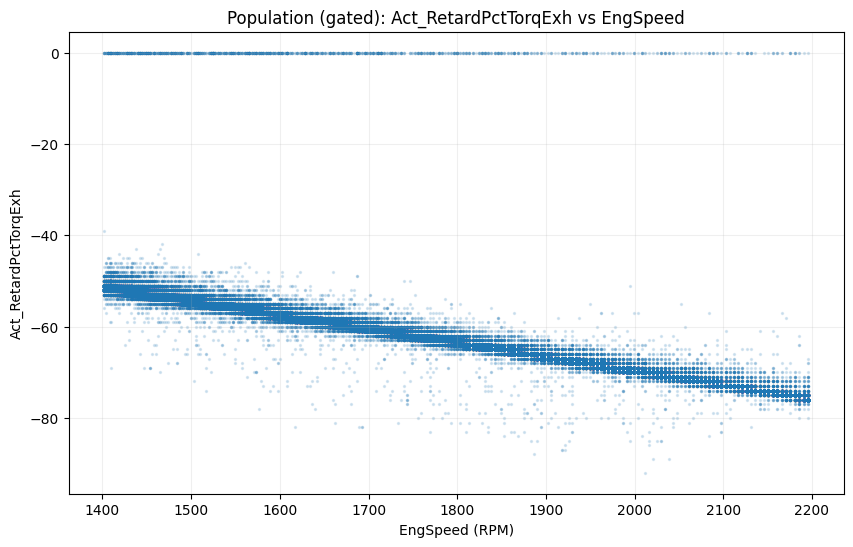

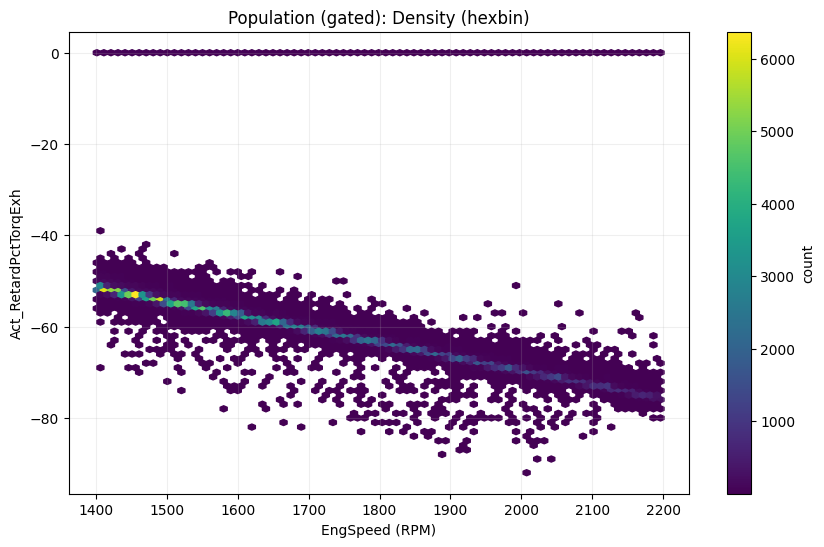

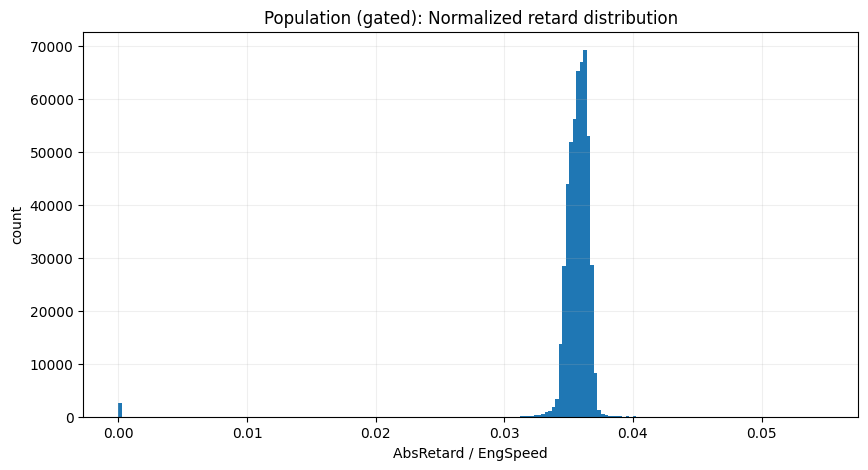

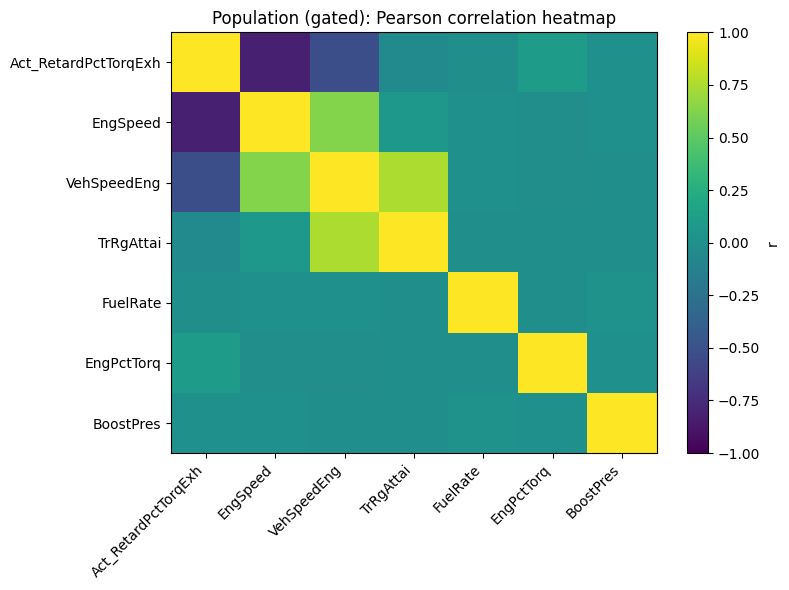

,Act_RetardPctTorqExh,EngSpeed,VehSpeedEng,TrRgAttai,FuelRate,EngPctTorq,BoostPres
Act_RetardPctTorqExh,1.000000,-0.823942,-0.522093,-0.053261,-0.001119,0.099181,0.006301
EngSpeed,-0.823942,1.000000,0.629779,0.065162,0.001079,-0.009361,0.001484
VehSpeedEng,-0.522093,0.629779,1.000000,0.756574,0.000556,-0.007835,-0.000396
TrRgAttai,-0.053261,0.065162,0.756574,1.000000,-0.000563,-0.004127,-0.001477
FuelRate,-0.001119,0.001079,0.000556,-0.000563,1.000000,-0.000098,0.021084
EngPctTorq,0.099181,-0.009361,-0.007835,-0.004127,-0.000098,1.000000,0.001364
BoostPres,0.006301,0.001484,-0.000396,-0.001477,0.021084,0.001364,1.000000


In [5]:

def sample_for_plot(d: pd.DataFrame, n: int = 300_000):
    if len(d) <= n:
        return d
    return d.sample(n, random_state=RANDOM_SEED)

d1 = sample_for_plot(g.dropna(subset=["EngSpeed","Act_RetardPctTorqExh"]), n=250_000)

plt.figure(figsize=(10,6))
plt.scatter(d1["EngSpeed"], d1["Act_RetardPctTorqExh"], s=2, alpha=0.15)
plt.xlabel("EngSpeed (RPM)")
plt.ylabel("Act_RetardPctTorqExh")
plt.title("Population (gated): Act_RetardPctTorqExh vs EngSpeed")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(10,6))
plt.hexbin(d1["EngSpeed"], d1["Act_RetardPctTorqExh"], gridsize=80, mincnt=1)
plt.xlabel("EngSpeed (RPM)")
plt.ylabel("Act_RetardPctTorqExh")
plt.title("Population (gated): Density (hexbin)")
plt.colorbar(label="count")
plt.grid(True, alpha=0.2)
plt.show()

d2 = g.replace([np.inf, -np.inf], np.nan).dropna(subset=["NormRetard_perRPM"])
d2 = sample_for_plot(d2, n=500_000)

plt.figure(figsize=(10,5))
plt.hist(d2["NormRetard_perRPM"], bins=200)
plt.xlabel("AbsRetard / EngSpeed")
plt.ylabel("count")
plt.title("Population (gated): Normalized retard distribution")
plt.grid(True, alpha=0.2)
plt.show()

FEATURES = [
    "Act_RetardPctTorqExh",
    "EngSpeed",
    "VehSpeedEng",
    "TrRgAttai",
    "FuelRate",
    "EngPctTorq",
    "BoostPres",
]

feat = [c for c in FEATURES if c in g.columns]
corr = g[feat].corr(method="pearson")

plt.figure(figsize=(8,6))
plt.imshow(corr.values, aspect="auto", vmin=-1, vmax=1)
plt.xticks(range(len(feat)), feat, rotation=45, ha="right")
plt.yticks(range(len(feat)), feat)
plt.title("Population (gated): Pearson correlation heatmap")
plt.colorbar(label="r")
plt.tight_layout()
plt.show()

corr


## 5) VIN-specific plots (compare a single VIN to population)

VIN02756 gated rows: 38177


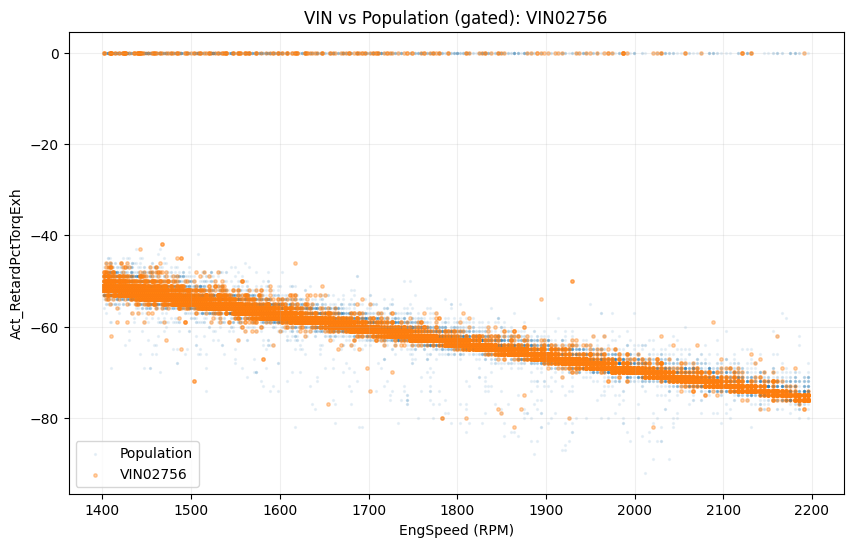

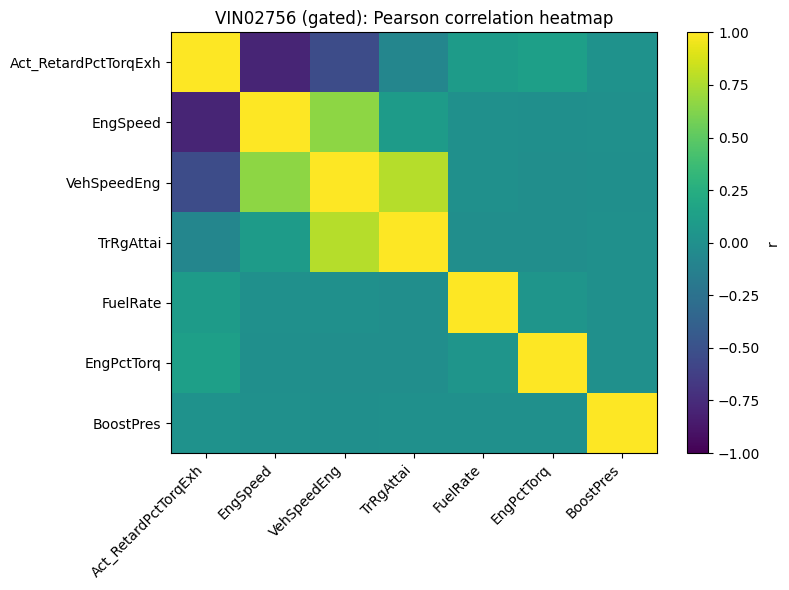

In [6]:

vin_pick = "VIN02756"  # edit
gv = g[g["vin"] == vin_pick]
print(vin_pick, "gated rows:", len(gv))

d_pop = sample_for_plot(g.dropna(subset=["EngSpeed","Act_RetardPctTorqExh"]), n=200_000)
d_vin = sample_for_plot(gv.dropna(subset=["EngSpeed","Act_RetardPctTorqExh"]), n=60_000)

plt.figure(figsize=(10,6))
plt.scatter(d_pop["EngSpeed"], d_pop["Act_RetardPctTorqExh"], s=2, alpha=0.08, label="Population")
plt.scatter(d_vin["EngSpeed"], d_vin["Act_RetardPctTorqExh"], s=6, alpha=0.35, label=vin_pick)
plt.xlabel("EngSpeed (RPM)")
plt.ylabel("Act_RetardPctTorqExh")
plt.title(f"VIN vs Population (gated): {vin_pick}")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

feat = [c for c in FEATURES if c in gv.columns]
if len(gv) > 200 and len(feat) >= 2:
    corr_v = gv[feat].corr(method="pearson")
    plt.figure(figsize=(8,6))
    plt.imshow(corr_v.values, aspect="auto", vmin=-1, vmax=1)
    plt.xticks(range(len(feat)), feat, rotation=45, ha="right")
    plt.yticks(range(len(feat)), feat)
    plt.title(f"{vin_pick} (gated): Pearson correlation heatmap")
    plt.colorbar(label="r")
    plt.tight_layout()
    plt.show()
    corr_v
else:
    print("Not enough rows/features for VIN correlation heatmap.")


## 6) Cluster probe (simple, label-free)

2D feature space:
- `EngSpeed`
- `AbsRetard / EngSpeed`


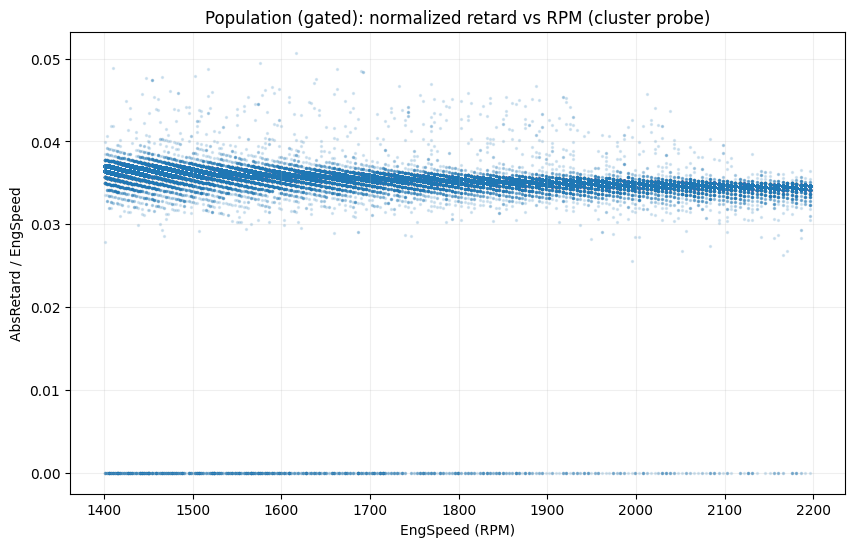

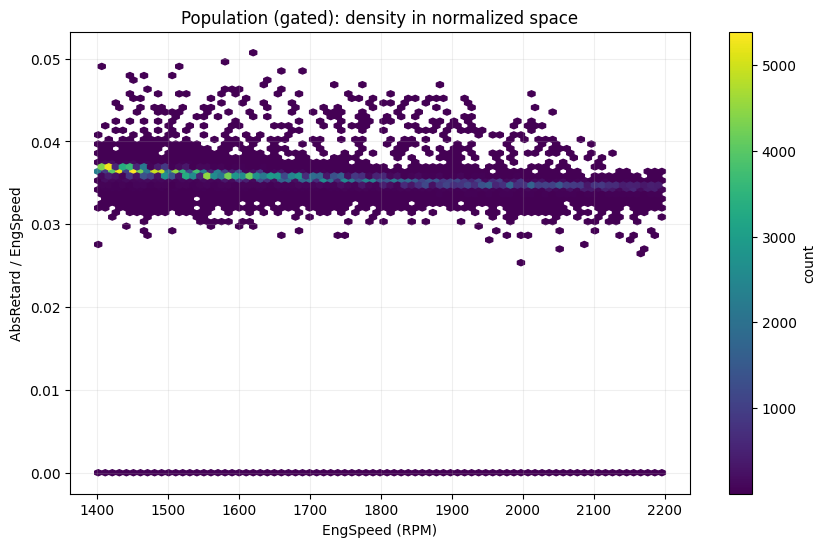

In [7]:

d3 = g.replace([np.inf, -np.inf], np.nan).dropna(subset=["EngSpeed","NormRetard_perRPM"])
d3 = sample_for_plot(d3, n=250_000)

plt.figure(figsize=(10,6))
plt.scatter(d3["EngSpeed"], d3["NormRetard_perRPM"], s=2, alpha=0.15)
plt.xlabel("EngSpeed (RPM)")
plt.ylabel("AbsRetard / EngSpeed")
plt.title("Population (gated): normalized retard vs RPM (cluster probe)")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(10,6))
plt.hexbin(d3["EngSpeed"], d3["NormRetard_perRPM"], gridsize=80, mincnt=1)
plt.xlabel("EngSpeed (RPM)")
plt.ylabel("AbsRetard / EngSpeed")
plt.title("Population (gated): density in normalized space")
plt.colorbar(label="count")
plt.grid(True, alpha=0.2)
plt.show()


## 7) Optional: slice by speed bands (individual plots)

speed_band values: ['20-35', '40-60', '5-15', 'other']


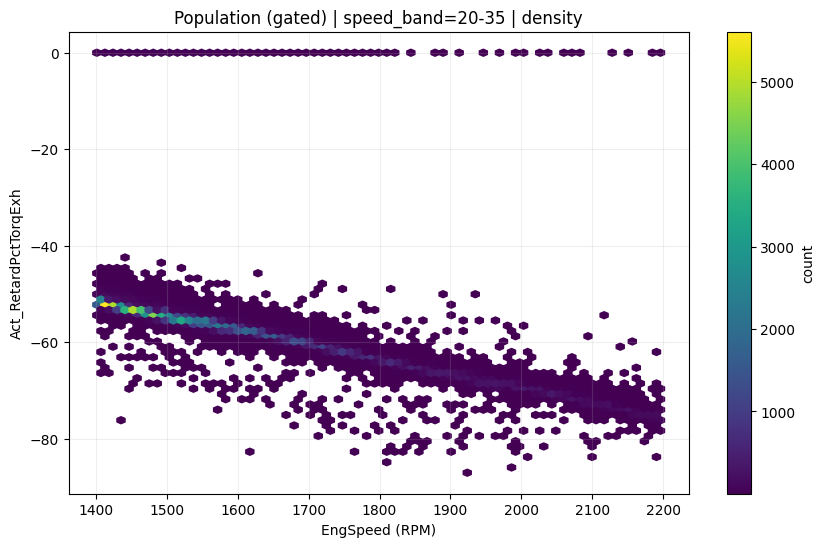

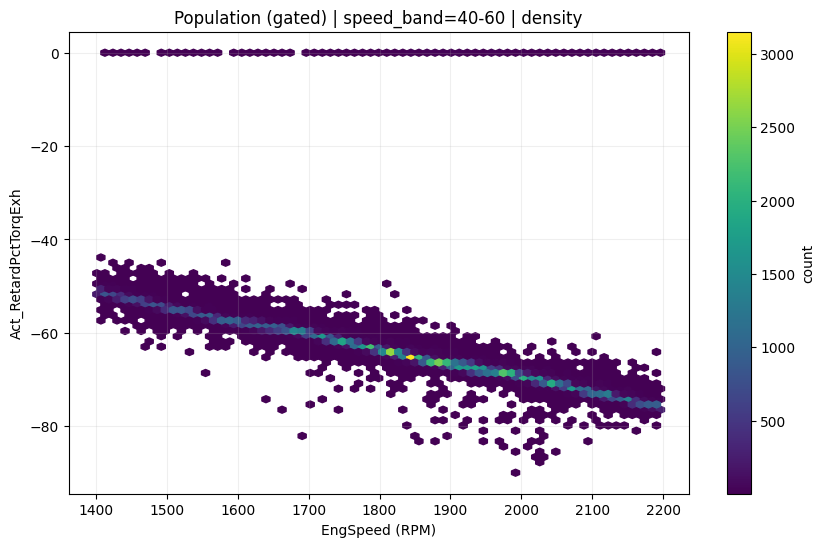

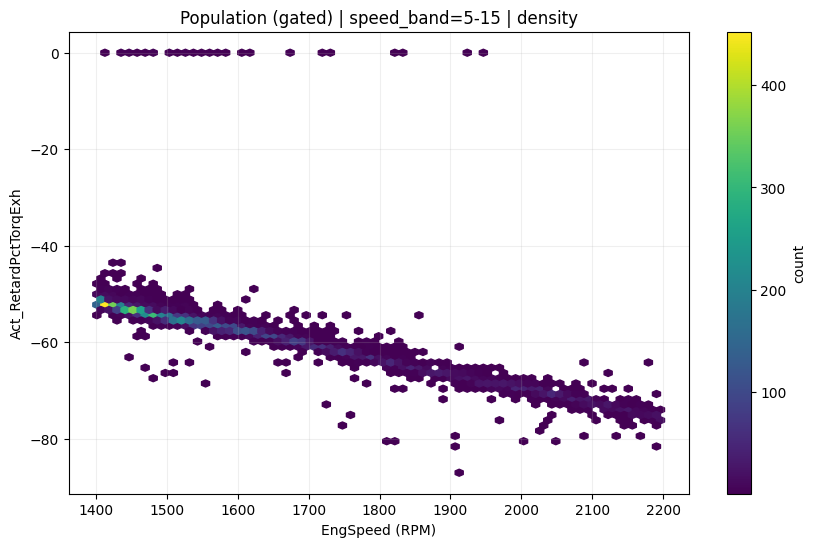

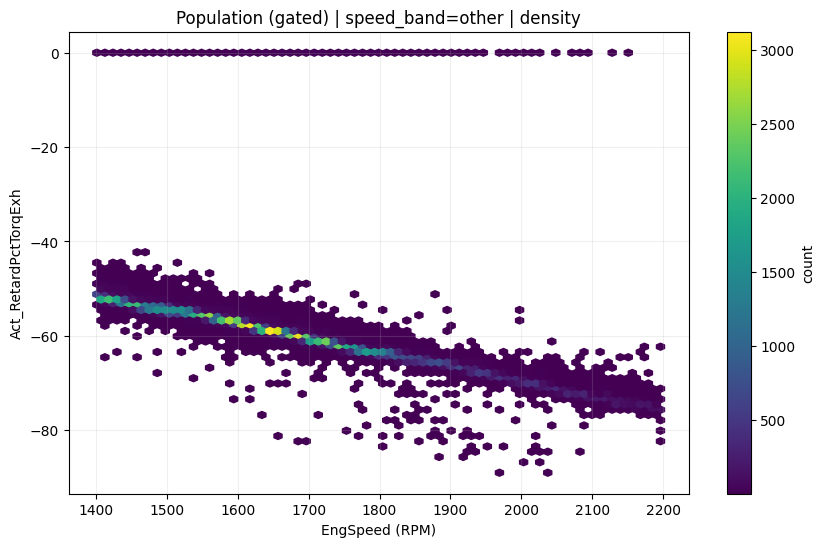

In [10]:

if "speed_band" in g.columns:
    bands = sorted([b for b in g["speed_band"].dropna().unique().tolist()])
    print("speed_band values:", bands)

    for b in bands:
        gb = g[g["speed_band"] == b].dropna(subset=["EngSpeed","Act_RetardPctTorqExh"])
        if len(gb) < 2000:
            continue
        gb = sample_for_plot(gb, n=120_000)

        plt.figure(figsize=(10,6))
        plt.hexbin(gb["EngSpeed"], gb["Act_RetardPctTorqExh"], gridsize=70, mincnt=1)
        plt.xlabel("EngSpeed (RPM)")
        plt.ylabel("Act_RetardPctTorqExh")
        plt.title(f"Population (gated) | speed_band={b} | density")
        plt.colorbar(label="count")
        plt.grid(True, alpha=0.2)
        plt.show()
else:
    print("No speed_band column found in gated dataset.")




Summarize **per event** (`vin,event_id`) and cluster events or VINs without using inspection labels.
